### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [1]:
# %pip install transformers scikit-learn

In [2]:
from transformers import CLIPProcessor, CLIPModel
import torch
from PIL import Image

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [3]:
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

In [4]:
import os
image_folder = "./images" if os.path.exists("./images") else "CLIP_Search/images"


In [5]:
# Updated Cell 5
import os
from PIL import Image

image_files = [
    os.path.join(image_folder, file) 
    for file in os.listdir(image_folder) 
    if file.lower().endswith(('png', 'jpg', 'jpeg'))
]

# Add .convert('RGB') to handle RGBA/grayscale images
images = [Image.open(file).convert('RGB') for file in image_files]

In [6]:
import os
target_image_path = "./images/cat1.jpg" if os.path.exists("./images/cat1.jpg") else "CLIP_Search/images/cat1.jpg"


In [7]:
target_image = Image.open(target_image_path).convert('RGB')

In [8]:
def extract_features(images):
    inputs = processor(images=images, return_tensors="pt")
    with torch.no_grad():
        features = model.get_image_features(**inputs)
    return features

target_features = extract_features([target_image])
image_features = extract_features(images)

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

# Extract the tensor from the output object, detach, move to CPU, and convert to numpy
target_vec = target_features.pooler_output.detach().cpu().numpy()
image_vecs = image_features.pooler_output.detach().cpu().numpy()

# Compute cosine similarity
similarities = cosine_similarity(target_vec, image_vecs).flatten()

# Get indices sorted by descending similarity
indices = similarities.argsort()[::-1]

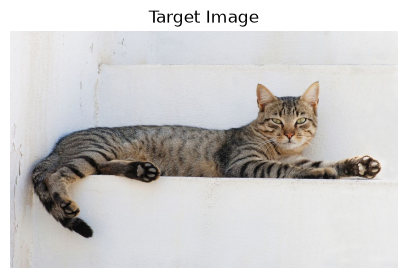

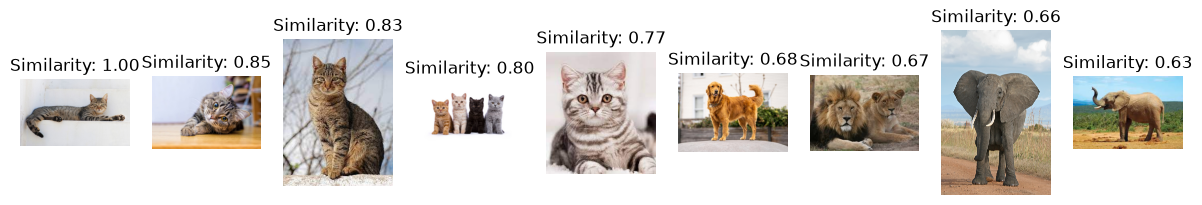

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(target_image)
plt.title("Target Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(15, 5))
for i, idx in enumerate(indices):
    plt.subplot(1, len(images), i + 1)
    plt.imshow(images[idx])  # idx is now a standard integer
    plt.title(f"Similarity: {similarities[idx]:.2f}")
    plt.axis("off")
plt.show()

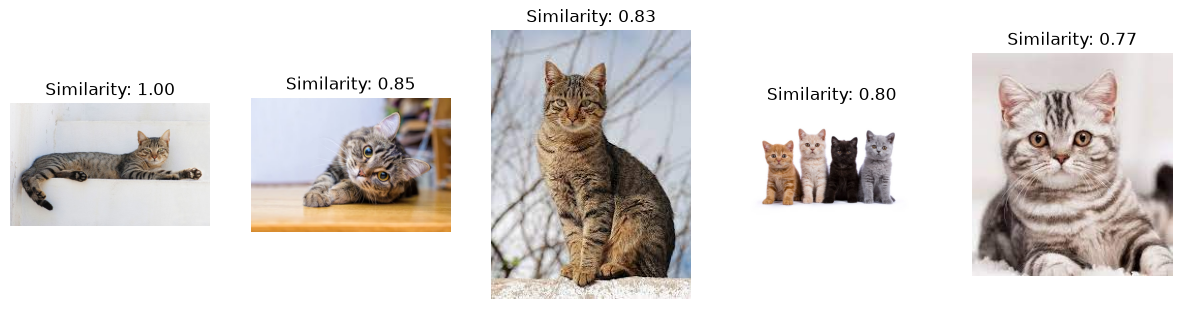

In [11]:
# 1. Flatten similarities into a 1D array
sims = similarities.flatten()

# 2. Filter and sort 
threshold = 0.75
filtered_indices = [i for i, sim in enumerate(sims) if sim >= threshold]
filtered_indices = sorted(filtered_indices, key=lambda i: sims[i], reverse=True)

# 3. Plot only the filtered results
if filtered_indices:
    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(filtered_indices):
        plt.subplot(1, len(filtered_indices), i + 1)
        plt.imshow(images[idx])
        plt.title(f"Similarity: {sims[idx]:.2f}")
        plt.axis("off")
    plt.show()
else:
    print(f"No images met the threshold of {threshold}")

In [12]:
def get_images(target_image_path, image_folder):
    target_image = Image.open(target_image_path)

    image_files = [os.path.join(image_folder, file) for file in os.listdir(image_folder) if file.lower().endswith(('png', 'jpg', 'jpeg'))]
    images = [Image.open(file) for file in image_files]

    if not images:
        print("No images found in the specified folder.")
        return

    target_features = extract_features([target_image])
    image_features = extract_features(images)

    similarities = cosine_similarity(target_features, image_features).flatten()

    threshold = 0.75
    filtered_indices = [i for i, sim in enumerate(similarities) if sim >= threshold]
    filtered_indices = sorted(filtered_indices, key=lambda i: similarities[i], reverse=True)

    if not filtered_indices:
        print(f"No images found with similarity >= {threshold}")
        return

    plt.figure(figsize=(15, 5))
    for i, idx in enumerate(filtered_indices):
        plt.subplot(1, len(filtered_indices), i + 1)
        plt.imshow(images[idx])
        plt.title(f"Similarity: {similarities[idx]:.2f}")
        plt.axis("off")
    plt.show()

In [13]:
import os
image_folder = "./images" if os.path.exists("./images") else "CLIP_Search/images"


In [18]:
import torch

def extract_features(images):
    model.to(device)
    
    # Process images into model input tensors
    inputs = processor(images=images, return_tensors="pt").to(device)

    with torch.no_grad():
        # 1. If using a CLIP-like model with explicit feature extraction
        if hasattr(model, "get_image_features"):
            features = model.get_image_features(**inputs)
        else:
            outputs = model(**inputs)
            
            # 2. Safely extract the tensor from BaseModelOutputWithPooling
            if getattr(outputs, "pooler_output", None) is not None:
                features = outputs.pooler_output
            elif getattr(outputs, "image_embeds", None) is not None:
                features = outputs.image_embeds
            elif getattr(outputs, "last_hidden_state", None) is not None:
                features = outputs.last_hidden_state[:, 0, :]  # Take [CLS] token representation
            elif isinstance(outputs, torch.Tensor):
                features = outputs
            else:
                raise TypeError(f"Unable to extract tensor features from output type {type(outputs)}")

    # 3. Normalize the tensor and convert to numpy array
    features = features / features.norm(p=2, dim=-1, keepdim=True)
    return features.cpu().numpy()

In [1]:
get_images(target_image_path, images)

NameError: name 'get_images' is not defined